# Policy Iteration & Value Iteration Visualization

This notebook visualizes two classic algorithms for solving MDPs:
- **Value Iteration**: Iteratively update value estimates until convergence
- **Policy Iteration**: Alternate between policy evaluation and policy improvement

We use a simple **5×5 maze** with walls, a start state, and a goal state.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrow
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output
import time
np.random.seed(42)

## Maze Environment

In [9]:
class MazeEnv:
    """
    A simple grid-world MDP.

    Legend:
      0 = free cell
      1 = wall
      2 = goal  (reward +10, terminal)
      3 = trap   (reward -5, terminal)

    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    Step reward: -0.1  (small cost to encourage shortest path)
    """

    # ── Maze layout ──────────────────────────────────────────────────────────
    GRID = np.array([
        [0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 3, 0],
        [0, 1, 0, 1, 1, 0, 0],
        [0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 2],
    ])

    ACTION_DELTAS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}  # up/down/left/right
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    ACTION_ARROWS  = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0)}

    def __init__(self, gamma: float = 0.95, step_reward: float = -0.1):
        self.grid   = self.GRID.copy()
        self.nrows, self.ncols = self.grid.shape
        self.gamma  = gamma
        self.step_r = step_reward
        self.start  = (0, 0)

        # Enumerate non-wall states
        self.states = [(r, c)
                       for r in range(self.nrows)
                       for c in range(self.ncols)
                       if self.grid[r, c] != 1]
        self.n_states  = len(self.states)
        self.n_actions = 4

    # ── helpers ──────────────────────────────────────────────────────────────
    def is_terminal(self, state):
        return self.grid[state] in (2, 3)

    def reward(self, state):
        v = self.grid[state]
        if v == 2: return 10.0
        if v == 3: return -5.0
        return self.step_r

    # Deterministic transitions
    def transitions(self, state, action):
        """Return list of (prob, next_state) for deterministic env."""
        if self.is_terminal(state):
            return [(1.0, state)]
        dr, dc = self.ACTION_DELTAS[action]
        nr, nc = state[0] + dr, state[1] + dc
        # Boundary / wall → stay
        if not (0 <= nr < self.nrows and 0 <= nc < self.ncols) or self.grid[nr, nc] == 1:
            return [(1.0, state)]
        return [(1.0, (nr, nc))]

    # Non-deterministic transitions (slipping)
    #def transitions(self, state, action):
    #    if self.is_terminal(state):
    #        return [(1.0, state)]
    #    
    #    # Define the two perpendicular "slip" actions for each action
    #    slip_actions = {
    #        0: (2, 3),  # Up    → can slip Left or Right
    #        1: (2, 3),  # Down  → can slip Left or Right
    #        2: (0, 1),  # Left  → can slip Up or Down
    #        3: (0, 1),  # Right → can slip Up or Down
    #    }
    #    
    #    def apply_action(s, a):
    #        dr, dc = self.ACTION_DELTAS[a]
    #        nr, nc = s[0] + dr, s[1] + dc
    #        if not (0 <= nr < self.nrows and 0 <= nc < self.ncols) or self.grid[nr, nc] == 1:
    #            return s  # bounce back to current state
    #        return (nr, nc)
    #    
    #    intended  = apply_action(state, action)
    #    slip_a, slip_b = slip_actions[action]
    #    slip_left  = apply_action(state, slip_a)
    #    slip_right = apply_action(state, slip_b)
    #    
    #    # Aggregate probabilities for identical outcomes
    #    probs = {}
    #    for prob, s in [(0.8, intended), (0.1, slip_left), (0.1, slip_right)]:
    #        probs[s] = probs.get(s, 0) + prob
    #    
    #    return [(prob, s) for s, prob in probs.items()]


env = MazeEnv()
print(f"Grid size : {env.nrows}×{env.ncols}")
print(f"Free cells: {env.n_states}")
print(f"Start     : {env.start}")
goal  = [(r,c) for (r,c) in env.states if env.grid[r,c]==2][0]
traps = [(r,c) for (r,c) in env.states if env.grid[r,c]==3]
print(f"Goal      : {goal}")
print(f"Traps     : {traps}")

Grid size : 7×7
Free cells: 39
Start     : (0, 0)
Goal      : (6, 6)
Traps     : [(2, 5)]


In [10]:
env.transitions((1,1), 1)

[(1.0, (2, 1))]

## Visualization Helper

In [11]:
def draw_maze_state(ax, env, V, policy=None,
                    title='', vmin=None, vmax=None,
                    show_values=True, cmap='RdYlGn'):
    """
    Render a single frame: heat-map of V + optional policy arrows.
    """
    nr, nc = env.nrows, env.ncols

    # Build display grid (NaN for walls so they appear grey)
    display_grid = np.full((nr, nc), np.nan)
    for (r, c) in env.states:
        display_grid[r, c] = V.get((r, c), 0)

    vmin = vmin if vmin is not None else np.nanmin(display_grid)
    vmax = vmax if vmax is not None else np.nanmax(display_grid)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad('dimgray')          # walls → dark grey

    ax.imshow(display_grid, cmap=cmap_obj,
              vmin=vmin, vmax=vmax,
              interpolation='nearest', aspect='equal')

    # Grid lines
    for x in range(nc + 1):
        ax.axvline(x - 0.5, color='white', lw=0.8)
    for y in range(nr + 1):
        ax.axhline(y - 0.5, color='white', lw=0.8)

    # Cell annotations
    for (r, c) in env.states:
        cell_type = env.grid[r, c]

        # Special markers
        if cell_type == 2:
            ax.text(c, r, '★', ha='center', va='center',
                    fontsize=16, color='gold', fontweight='bold')
        elif cell_type == 3:
            ax.text(c, r, '✗', ha='center', va='center',
                    fontsize=14, color='black', fontweight='bold')
        elif (r, c) == env.start:
            ax.text(c, r, 'S', ha='center', va='center',
                    fontsize=11, color='navy', fontweight='bold')

        # Value text
        if show_values and not env.is_terminal((r, c)):
            val = V.get((r, c), 0)
            ax.text(c, r + 0.38, f'{val:.1f}',
                    ha='center', va='center',
                    fontsize=6.5, color='black', alpha=0.85)

        # Policy arrow
        if policy and not env.is_terminal((r, c)):
            a = policy.get((r, c))
            if a is not None:
                dx, dy = env.ACTION_ARROWS[a]
                ax.annotate('', xy=(c + dx, r + dy), xytext=(c, r),
                            arrowprops=dict(arrowstyle='->', color='black',
                                           lw=1.4))

    ax.set_title(title, fontsize=10, pad=4)
    ax.set_xticks([])
    ax.set_yticks([])


print("Visualization helper defined.")

Visualization helper defined.


## Value Iteration

In [12]:
def value_iteration(env, theta=1e-4, max_iter=200, snapshot_every=1):
    """
    Classic Value Iteration.  Returns a list of (V_snapshot, policy_snapshot, delta).
    """
    V = {s: 0.0 for s in env.states}
    snapshots = []   # list of (V_copy, policy_copy, delta, iteration)

    for it in range(1, max_iter + 1):
        delta = 0.0
        new_V = {}

        for s in env.states:
            if env.is_terminal(s):
                new_V[s] = env.reward(s)
                continue

            q_values = []
            for a in range(env.n_actions):
                q = sum(p * (env.reward(s) + env.gamma * V[s_])
                        for p, s_ in env.transitions(s, a))
                q_values.append(q)

            new_V[s] = max(q_values)
            delta = max(delta, abs(new_V[s] - V[s]))

        V = new_V

        # Extract greedy policy
        policy = {}
        for s in env.states:
            if env.is_terminal(s): continue
            q_values = [sum(p * (env.reward(s) + env.gamma * V[s_])
                           for p, s_ in env.transitions(s, a))
                        for a in range(env.n_actions)]
            policy[s] = int(np.argmax(q_values))

        if it % snapshot_every == 0 or delta < theta:
            snapshots.append((V.copy(), policy.copy(), delta, it))

        if delta < theta:
            print(f"Value Iteration converged in {it} iterations (Δ={delta:.6f})")
            break

    return snapshots


vi_snapshots = value_iteration(env)
print(f"Snapshots recorded: {len(vi_snapshots)}")

Value Iteration converged in 14 iterations (Δ=0.000000)
Snapshots recorded: 14


## Policy Iteration

In [13]:
def policy_evaluation(env, policy, theta=1e-4, max_iter=500):
    """Full policy evaluation until convergence."""
    V = {s: 0.0 for s in env.states}
    for _ in range(max_iter):
        delta = 0.0
        for s in env.states:
            if env.is_terminal(s):
                V[s] = env.reward(s)
                continue
            a = policy[s]
            v = sum(p * (env.reward(s) + env.gamma * V[s_])
                    for p, s_ in env.transitions(s, a))
            delta = max(delta, abs(v - V[s]))
            V[s] = v
        if delta < theta:
            break
    return V


def policy_iteration(env, max_iter=50):
    """
    Classic Policy Iteration.  Returns a list of (V, policy, iteration) snapshots,
    one per policy-improvement step.
    """
    # Initialise with random policy
    policy = {s: np.random.randint(env.n_actions)
              for s in env.states if not env.is_terminal(s)}
    snapshots = []

    for it in range(1, max_iter + 1):
        # ---- Evaluation ----
        V = policy_evaluation(env, policy)

        # ---- Improvement ----
        policy_stable = True
        new_policy = {}
        for s in env.states:
            if env.is_terminal(s): continue
            q_values = [sum(p * (env.reward(s) + env.gamma * V[s_])
                           for p, s_ in env.transitions(s, a))
                        for a in range(env.n_actions)]
            best_a = int(np.argmax(q_values))
            new_policy[s] = best_a
            if best_a != policy[s]:
                policy_stable = False

        policy = new_policy
        snapshots.append((V.copy(), policy.copy(), it))

        if policy_stable:
            print(f"Policy Iteration converged in {it} iterations")
            break

    return snapshots


pi_snapshots = policy_iteration(env)
print(f"Snapshots recorded: {len(pi_snapshots)}")

Policy Iteration converged in 12 iterations
Snapshots recorded: 12


## Static Overview

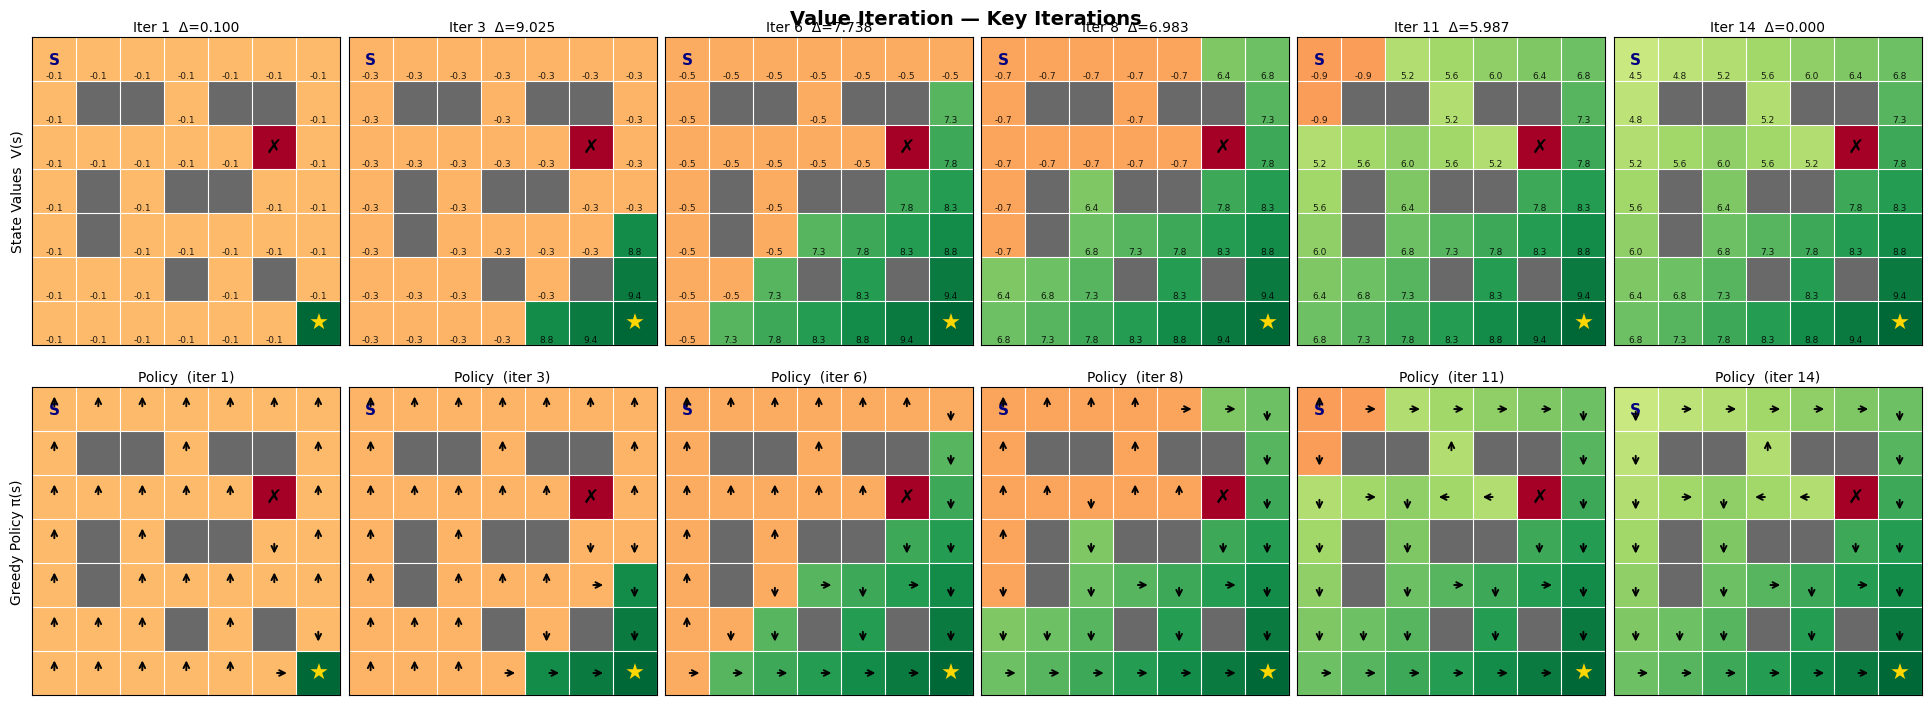

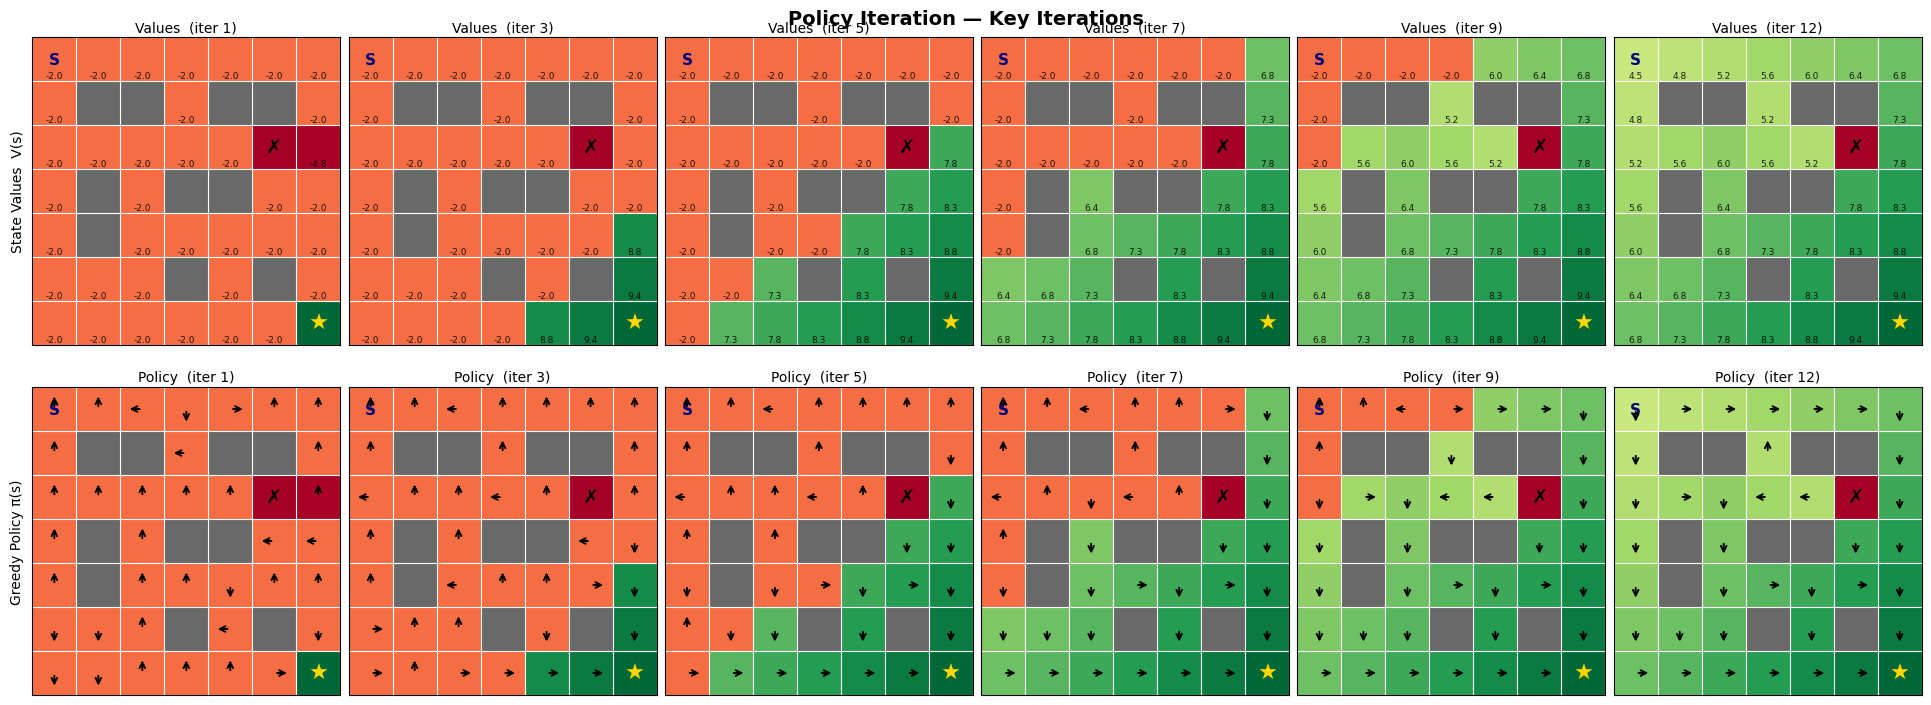

In [14]:
def plot_algorithm_overview(snapshots, algorithm_name, indices=None,
                            is_vi=True):
    """
    Display a grid of key snapshots side-by-side.
    """
    if indices is None:
        # Pick ~6 evenly spaced frames + last
        n = len(snapshots)
        chosen = sorted(set([int(i * (n-1) / 5) for i in range(6)] + [n-1]))
        indices = chosen[:6]

    n_frames = len(indices)
    fig, axes = plt.subplots(2, n_frames, figsize=(3.2 * n_frames, 7),
                             constrained_layout=True)
    fig.suptitle(f'{algorithm_name} — Key Iterations', fontsize=14,
                 fontweight='bold', y=1.01)

    # Collect all values to fix colour scale
    all_vals = []
    for idx in indices:
        V = snapshots[idx][0]
        all_vals.extend(V.values())
    vmin, vmax = min(all_vals), max(all_vals)

    for col, idx in enumerate(indices):
        if is_vi:
            V, pol, delta, it = snapshots[idx]
            subtitle_top  = f'Iter {it}  Δ={delta:.3f}'
            subtitle_bot  = f'Policy  (iter {it})'
        else:
            V, pol, it = snapshots[idx]
            subtitle_top  = f'Values  (iter {it})'
            subtitle_bot  = f'Policy  (iter {it})'

        # Top row — values only
        draw_maze_state(axes[0, col], env, V, policy=None,
                        title=subtitle_top,
                        vmin=vmin, vmax=vmax,
                        show_values=True)
        # Bottom row — policy arrows
        draw_maze_state(axes[1, col], env, V, policy=pol,
                        title=subtitle_bot,
                        vmin=vmin, vmax=vmax,
                        show_values=False)

    # Row labels
    axes[0, 0].set_ylabel('State Values  V(s)', fontsize=10, labelpad=6)
    axes[1, 0].set_ylabel('Greedy Policy π(s)', fontsize=10, labelpad=6)

    plt.savefig(f'{algorithm_name.lower().replace(" ","_")}_overview.png',
                dpi=150, bbox_inches='tight')
    plt.show()


plot_algorithm_overview(vi_snapshots, 'Value Iteration',   is_vi=True)
plot_algorithm_overview(pi_snapshots, 'Policy Iteration',  is_vi=False)

## Side-by-Side Final Comparison

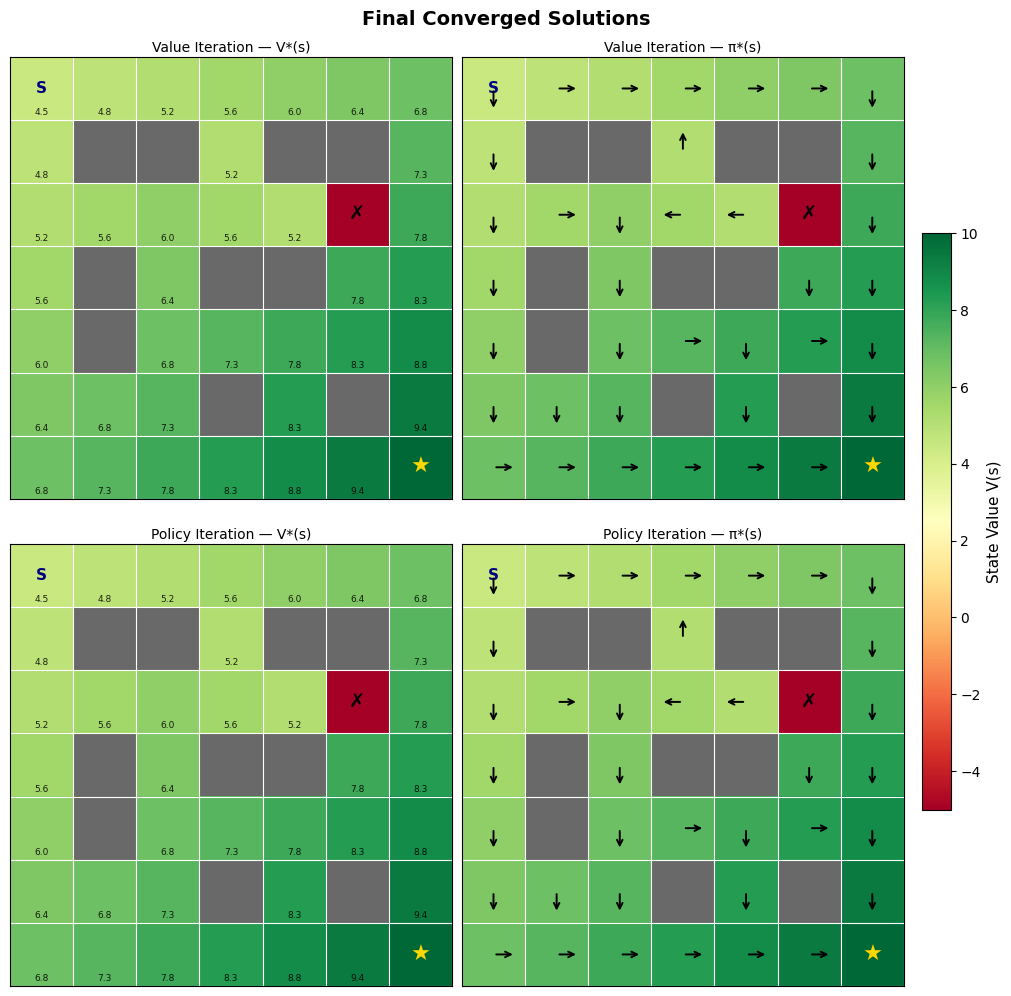

Max |V_VI(s) - V_PI(s)| = 0.000000  (should be ≈ 0)
Policies identical: True


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
fig.suptitle('Final Converged Solutions', fontsize=14, fontweight='bold')

vi_V,  vi_pol,  _, _  = vi_snapshots[-1]
pi_V,  pi_pol,  _     = pi_snapshots[-1]

all_v = list(vi_V.values()) + list(pi_V.values())
vmin, vmax = min(all_v), max(all_v)

draw_maze_state(axes[0, 0], env, vi_V, policy=None,
                title='Value Iteration — V*(s)',
                vmin=vmin, vmax=vmax, show_values=True)
draw_maze_state(axes[0, 1], env, vi_V, policy=vi_pol,
                title='Value Iteration — π*(s)',
                vmin=vmin, vmax=vmax, show_values=False)
draw_maze_state(axes[1, 0], env, pi_V, policy=None,
                title='Policy Iteration — V*(s)',
                vmin=vmin, vmax=vmax, show_values=True)
draw_maze_state(axes[1, 1], env, pi_V, policy=pi_pol,
                title='Policy Iteration — π*(s)',
                vmin=vmin, vmax=vmax, show_values=False)

# Colour bar
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                            norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('State Value V(s)', fontsize=11)

plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Sanity check: both algorithms should agree
max_diff = max(abs(vi_V[s] - pi_V[s]) for s in env.states)
print(f"Max |V_VI(s) - V_PI(s)| = {max_diff:.6f}  (should be ≈ 0)")
policies_agree = all(vi_pol.get(s) == pi_pol.get(s) for s in env.states if not env.is_terminal(s))
print(f"Policies identical: {policies_agree}")

## Animations

Runs in a loop — each frame shows how V and π change over time.
Re-run the cell to replay.

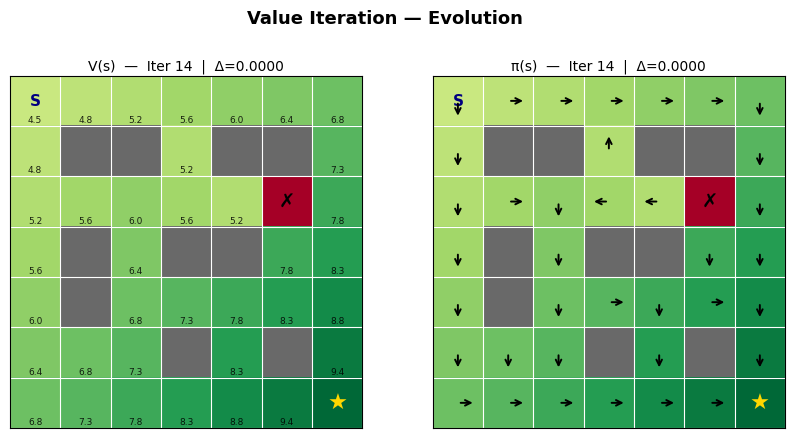

Value Iteration animation complete (14 frames).


In [16]:
def animate_algorithm(snapshots, algorithm_name, is_vi=True,
                      pause=0.4, max_frames=30):
    """
    Inline animation: iterates through snapshots and updates the figure in place.
    """
    # Subsample if too many frames
    n = len(snapshots)
    if n > max_frames:
        step = max(1, n // max_frames)
        frames = list(range(0, n, step))
        if frames[-1] != n - 1:
            frames.append(n - 1)
    else:
        frames = list(range(n))

    all_vals = [v for snap in snapshots for v in snap[0].values()]
    vmin, vmax = min(all_vals), max(all_vals)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'{algorithm_name} — Evolution', fontsize=13, fontweight='bold')

    for fi in frames:
        if is_vi:
            V, pol, delta, it = snapshots[fi]
            info = f'Iter {it}  |  Δ={delta:.4f}'
        else:
            V, pol, it = snapshots[fi]
            info = f'Policy Improvement Step {it}'

        for ax in axes:
            ax.cla()

        draw_maze_state(axes[0], env, V, policy=None,
                        title=f'V(s)  —  {info}',
                        vmin=vmin, vmax=vmax, show_values=True)
        draw_maze_state(axes[1], env, V, policy=pol,
                        title=f'π(s)  —  {info}',
                        vmin=vmin, vmax=vmax, show_values=False)

        clear_output(wait=True)
        display(fig)
        time.sleep(pause)

    plt.close(fig)
    print(f"{algorithm_name} animation complete ({len(frames)} frames).")


print("Animating Value Iteration …")
animate_algorithm(vi_snapshots, 'Value Iteration', is_vi=True, pause=0.35)

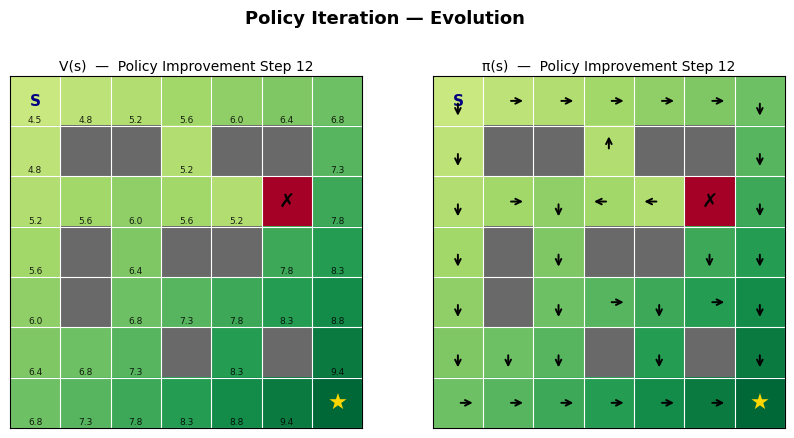

Policy Iteration animation complete (12 frames).


In [17]:
print("Animating Policy Iteration …")
animate_algorithm(pi_snapshots, 'Policy Iteration', is_vi=False, pause=0.7)